# Image Processing Notebook (Easy Notes)

## Overview
This notebook shows how to load an image from the internet and study its colors.
We look at the color channels (Red, Green, Blue), and we also turn the image into grayscale in two ways.

## Topics Used
- OpenCV (`cv2`)
- NumPy arrays
- Matplotlib plotting
- Reading image data from a URL with `requests`
- BGR vs RGB color order
- Channel splitting and merging
- Custom grayscale formula vs OpenCV grayscale


## Step 1: Import libraries
We import tools for image loading, math, and drawing images.

In [1]:
# OpenCV: image processing library
import cv2

# NumPy: works with arrays and numbers
import numpy as np

# Matplotlib: shows images and charts
import matplotlib.pyplot as plt

# Requests: downloads data from the web
import requests


## Step 2: Download and decode the image
OpenCV needs image bytes converted into an array, then decoded into an image matrix.

In [2]:
# URL of the image we want to use
url = "https://raymondmcguire.github.io/GPU-Based-Image-Processing-Tools/tools_webgl/FilterViewer/image/anim.png?raw=true"

# Download raw bytes from the URL
resp = requests.get(url, stream=True).raw

# Turn downloaded bytes into a NumPy array of numbers (0 to 255)
arr = np.asarray(bytearray(resp.read()), dtype="uint8")

# Decode that array into an OpenCV image (OpenCV reads as BGR)
img = cv2.imdecode(arr, cv2.IMREAD_COLOR)


## Step 3: Check basic image info and display it
We print simple facts about the image, then convert BGR to RGB so it looks correct in Matplotlib.

Shape: (512, 512, 3)
Data type: uint8
Min pixel value: 0
Max pixel value: 255


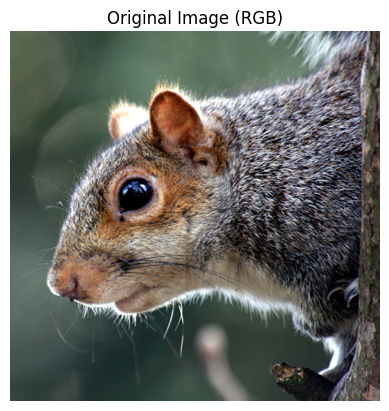

In [3]:
# Print image shape: (height, width, color channels)
print("Shape:", img.shape)

# Print data type (usually uint8 for images)
print("Data type:", img.dtype)

# Print darkest and brightest pixel values
print("Min pixel value:", img.min())
print("Max pixel value:", img.max())

# Convert BGR (OpenCV style) to RGB (Matplotlib style)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Show the image
plt.imshow(img_rgb)
plt.title("Original Image (RGB)")
plt.axis("off")
plt.show()


## Step 4: Split into Red, Green, and Blue channels
Each channel is a grayscale map that shows how strong that color is in each pixel.

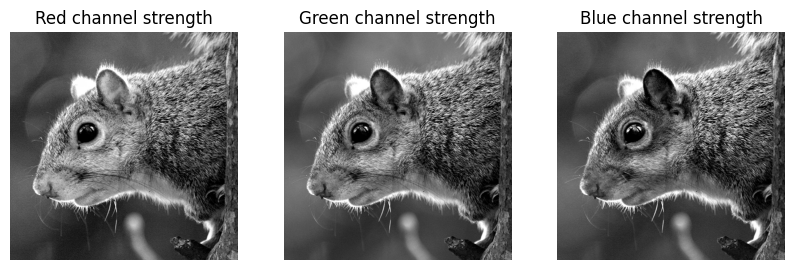

In [4]:
# Split image into Blue, Green, Red channels
b, g, r = cv2.split(img)

# Show each channel as grayscale
plt.figure(figsize=(10, 5))

plt.subplot(1, 3, 1)
plt.imshow(r, cmap='gray')
plt.title("Red channel strength")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(g, cmap='gray')
plt.title("Green channel strength")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(b, cmap='gray')
plt.title("Blue channel strength")
plt.axis("off")

plt.show()


## Step 5: Build pure red/green/blue images
We keep one channel and set the other two channels to zero.

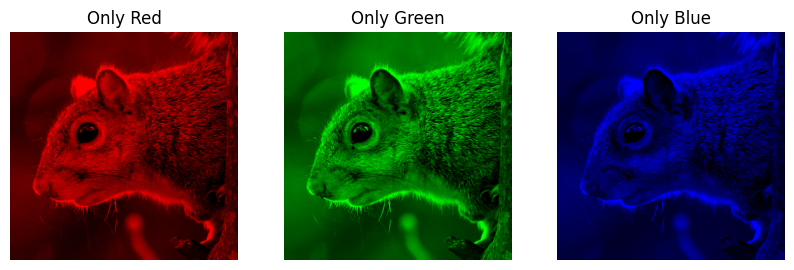

In [5]:
# Create a zero matrix (same size as one channel)
z = np.zeros_like(r)

# Keep only one channel at a time
red_bgr = cv2.merge([z, z, r])
green_bgr = cv2.merge([z, g, z])
blue_bgr = cv2.merge([b, z, z])

# Convert each result to RGB for correct display in Matplotlib
red = cv2.cvtColor(red_bgr, cv2.COLOR_BGR2RGB)
green = cv2.cvtColor(green_bgr, cv2.COLOR_BGR2RGB)
blue = cv2.cvtColor(blue_bgr, cv2.COLOR_BGR2RGB)

# Show color-isolated images
plt.figure(figsize=(10, 5))

plt.subplot(1, 3, 1)
plt.imshow(red)
plt.title("Only Red")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(green)
plt.title("Only Green")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(blue)
plt.title("Only Blue")
plt.axis("off")

plt.show()


## Step 6: Make grayscale in two ways and compare
Method A: Custom formula (more weight to red here).
Method B: OpenCV built-in grayscale conversion.

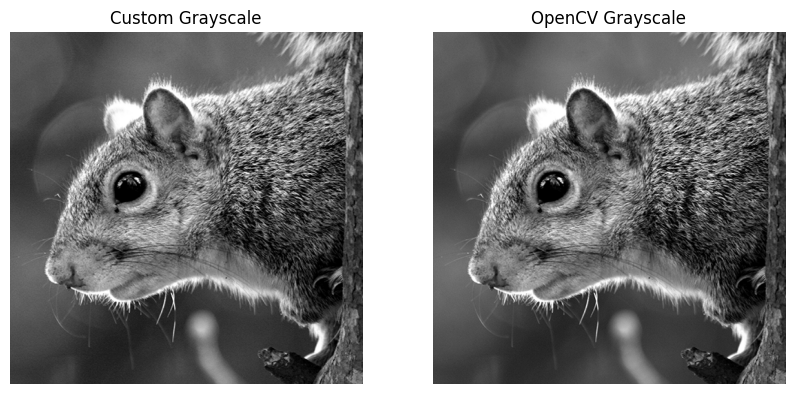

In [6]:
# Custom grayscale formula using weighted sum of channels
custom = (0.6 * r) + (0.3 * g) + (0.1 * b)

# Convert to uint8 so values match image format
custom = custom.astype(np.uint8)

# OpenCV grayscale conversion
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Show side-by-side comparison
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(custom, cmap='gray')
plt.title("Custom Grayscale")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(gray, cmap='gray')
plt.title("OpenCV Grayscale")
plt.axis("off")

plt.show()


## Quick Summary
- We loaded an image from a URL.
- We learned that OpenCV uses **BGR** order, not RGB.
- We split and visualized color channels.
- We made grayscale with a custom formula and with OpenCV.
- We compared both grayscale outputs.